# Análisis de Rendimiento de RetailNow
## Trabajo 3 – UNIR
### Autor: Diana C. Rodríguez Casas
### Objetivo:
Analizar datos de ventas, inventarios y satisfacción del cliente utilizando Pandas y Numpy, aplicando buenas prácticas de seguridad y DevSecOps.


In [40]:
sns.set_theme(style="whitegrid", palette="magma")
import pandas as pd
import numpy as np

np.random.seed(42)
print("Entorno listo para análisis seguro y reproducible ✅")

Entorno listo para análisis seguro y reproducible ✅


In [9]:
# --- Carga de datos ---
try:
    sales = pd.read_csv("sales.csv")
    inventories = pd.read_csv("inventories.csv")
    satisfaction = pd.read_csv("satisfaction.csv")

    print("Archivos cargados correctamente ✅")
except FileNotFoundError as e:
    print(f"Error: {e}\nVerifica las rutas y nombres de los archivos CSV.")

Archivos cargados correctamente ✅


In [24]:
# --- Exploración de ventas ---
sales["Revenue"] = sales["Cantidad_Vendida"] * sales["Precio_Unitario"]

ventas_por_tienda = sales.groupby("ID_Tienda")["Cantidad_Vendida"].sum()
ingresos_por_tienda = sales.groupby("ID_Tienda")["Revenue"].sum()
resumen_ventas = sales["Revenue"].describe()

print("Resumen de ventas por tienda:")
print(ingresos_por_tienda)
print("\nEstadísticas generales:")
print(resumen_ventas)

Resumen de ventas por tienda:
ID_Tienda
1     5000
2    10500
3     9000
4    13000
5    13000
Name: Revenue, dtype: int64

Estadísticas generales:
count       10.000000
mean      5050.000000
std       3361.960407
min       1000.000000
25%       2625.000000
50%       3500.000000
75%       7875.000000
max      10500.000000
Name: Revenue, dtype: float64


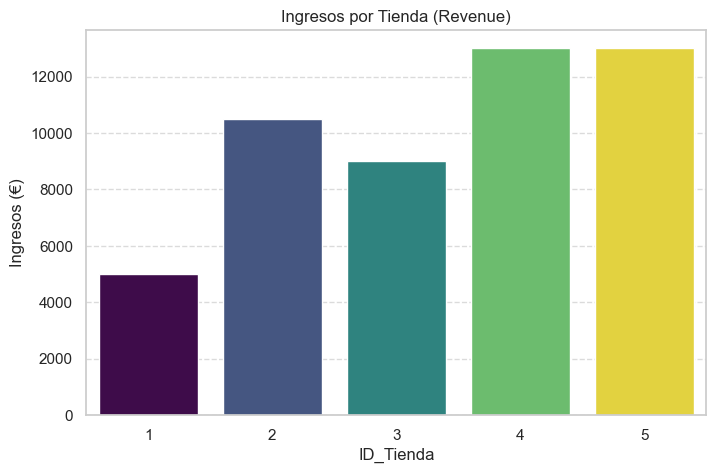

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# --- Visualización de ingresos por tienda ---
plt.figure(figsize=(8,5))
sns.barplot(x=ingresos_por_tienda.index, y=ingresos_por_tienda.values, hue=ingresos_por_tienda.index, palette="viridis", legend=False)

plt.title("Ingresos por Tienda (Revenue)")
plt.xlabel("ID_Tienda")
plt.ylabel("Ingresos (€)")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

In [26]:
# --- Ventas totales por producto ---
ventas_por_producto = sales.groupby("Producto")["Cantidad_Vendida"].sum()
print("\nVentas totales por producto:")
print(ventas_por_producto)

# --- Ventas totales por tienda ---
ventas_por_tienda = sales.groupby("ID_Tienda")["Cantidad_Vendida"].sum()
print("\nVentas totales por tienda:")
print(ventas_por_tienda)


Ventas totales por producto:
Producto
Producto A    85
Producto B    75
Producto C    90
Name: Cantidad_Vendida, dtype: int64

Ventas totales por tienda:
ID_Tienda
1    35
2    55
3    50
4    60
5    50
Name: Cantidad_Vendida, dtype: int64


In [27]:
# --- Crear categoría artificial ---
sales["Categoria"] = sales["Producto"].apply(lambda x: x.split()[0])

# --- Promedio de ventas por tienda y categoría ---
promedio_por_categoria = sales.groupby(["ID_Tienda", "Categoria"])["Cantidad_Vendida"].mean()
print("\nPromedio de ventas por tienda y categoría:")
print(promedio_por_categoria)


Promedio de ventas por tienda y categoría:
ID_Tienda  Categoria
1          Producto     17.5
2          Producto     27.5
3          Producto     25.0
4          Producto     30.0
5          Producto     25.0
Name: Cantidad_Vendida, dtype: float64


In [28]:
# --- Rotación de inventarios ---
ventas_por_tienda_df = ventas_por_tienda.reset_index()
inventories = inventories.merge(ventas_por_tienda_df, on="ID_Tienda")

inventories["Rotacion"] = inventories["Cantidad_Vendida"] / inventories["Stock_Disponible"]
inventarios_criticos = inventories[inventories["Rotacion"] < 0.10]

print("\nInventarios críticos (<10% rotación):")
print(inventarios_criticos)


Inventarios críticos (<10% rotación):
Empty DataFrame
Columns: [ID_Tienda, Producto, Stock_Disponible, Fecha_Actualización, Cantidad_Vendida, Rotacion]
Index: []


In [29]:
satisfaccion_baja = satisfaction[satisfaction["Satisfacción_Promedio"] < 60]
print("\nTiendas con satisfacción <60%:")
print(satisfaccion_baja)


Tiendas con satisfacción <60%:
   ID_Tienda  Satisfacción_Promedio Fecha_Evaluación
4          5                     55       2023-01-15


In [30]:
# --- Relación entre ventas y satisfacción ---
relacion = ventas_por_tienda_df.merge(
    satisfaction[["ID_Tienda", "Satisfacción_Promedio"]],
    on="ID_Tienda"
)

print("\nRelación entre ventas y satisfacción:")
print(relacion)


Relación entre ventas y satisfacción:
   ID_Tienda  Cantidad_Vendida  Satisfacción_Promedio
0          1                35                     85
1          2                55                     90
2          3                50                     70
3          4                60                     65
4          5                50                     55


In [31]:
# --- Recomendaciones ---
print("\nRecomendaciones para tiendas con satisfacción <60%:\n")

for _, row in satisfaccion_baja.iterrows():
    tienda = row["ID_Tienda"]
    print(f"- Tienda {tienda}:")
    print("  * Mejorar tiempos de atención y soporte postventa.")
    print("  * Implementar encuestas rápidas tras cada compra.")
    print("  * Revisar productos con más devoluciones o quejas.")
    print("  * Ofrecer promociones para recuperar confianza.\n")


Recomendaciones para tiendas con satisfacción <60%:

- Tienda 5:
  * Mejorar tiempos de atención y soporte postventa.
  * Implementar encuestas rápidas tras cada compra.
  * Revisar productos con más devoluciones o quejas.
  * Ofrecer promociones para recuperar confianza.



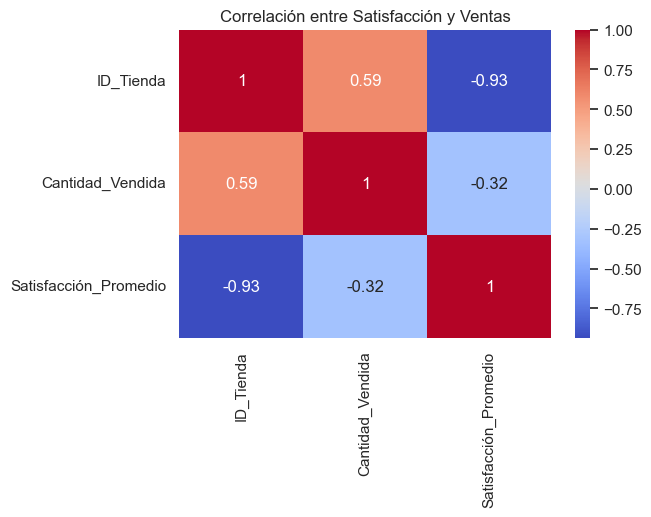

In [42]:
import seaborn as sns
import matplotlib.pyplot as plt

# --- Heatmap de correlación ---
plt.figure(figsize=(6,4))
sns.heatmap(relacion.corr(), annot=True, cmap="coolwarm")
plt.title("Correlación entre Satisfacción y Ventas")
plt.show()

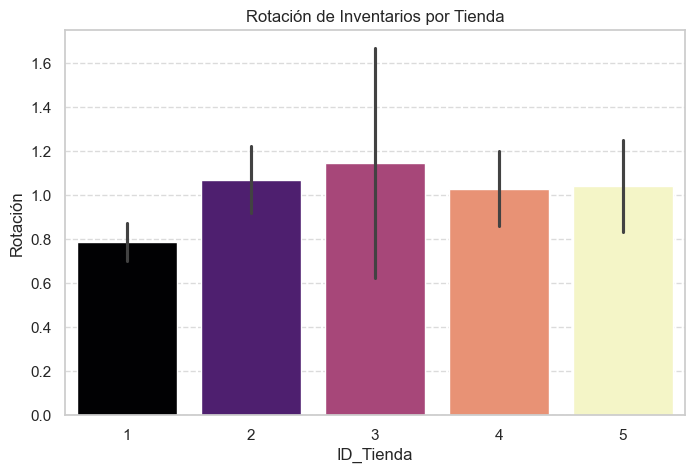

In [43]:
plt.figure(figsize=(8,5))
sns.barplot(data=inventories, x="ID_Tienda", y="Rotacion", hue="ID_Tienda", palette="magma", legend=False)
plt.title("Rotación de Inventarios por Tienda")
plt.xlabel("ID_Tienda")
plt.ylabel("Rotación")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()